In [4]:
#Import the wine dataset using the sklearn.datasets.load_wine function.
from sklearn.datasets import load_wine

In [5]:
#Print the keys of the dictionary
print(list(load_wine().keys()))

['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names']


In [10]:
#One of the keys in the dictionary is the description, ’DESRC’, giving a short description of the dataset
#and the features. Print the description.
print(load_wine().DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [ ]:
#From intuition, which of the features do you think is most strongly correlated with wine variety?

#Flavanoids & Total Phenols 

In [12]:
#Load the features and target values into a single pandas dataframe. Assign names to the columns using
#the ’feature_names’.
import pandas as pd
wine=load_wine()
df=pd.DataFrame(wine.data, columns=wine.feature_names)
print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [13]:
#Show some statistical properties of the data using df.describe().
print(df.describe())

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

In [ ]:
#How many samples, or instances, of each class are contained in the dataset?

#178 instances of each class 

In [15]:
#Is this a balanced dataset? Or is the data imbalanced?
df['target'] = wine.target
print(df['target'].value_counts().sort_index())

#This is a balanced dataset 

target
0    59
1    71
2    48
Name: count, dtype: int64


#What problems can arise when dealing with an imbalanced dataset?

#A model can lean towards one type of wine(bais) when the dataset is inbalenced. If the model then makes a predection it will gues the type of wine it favours and it will be right most of the time. 

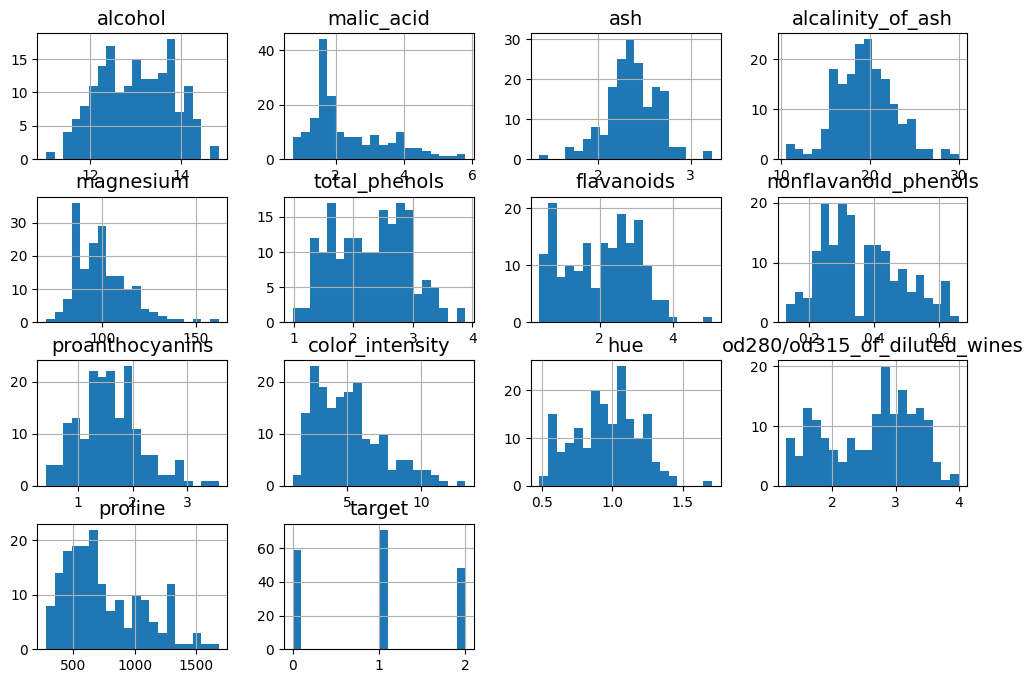

In [27]:
import matplotlib.pyplot as plt 

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

df.hist(bins=20, figsize=(12, 8), layout=(4, 4))

plt.show()


In [ ]:
#The data is distributed normally, with some outliers. The data is not skewed.

In [ ]:
#Make a selection in the dataframe of only classes 0 and 2.

print(df[df['target'].isin([0, 2])])


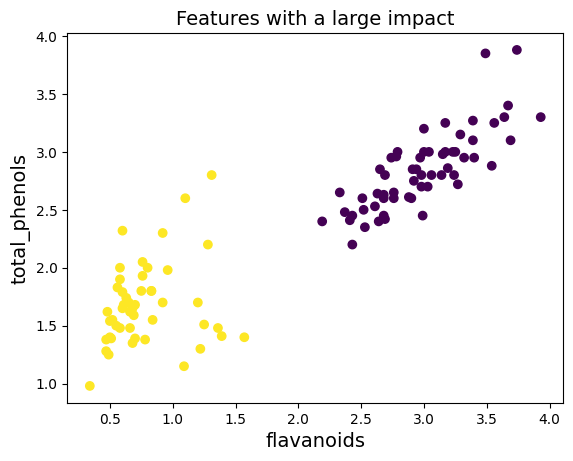

In [42]:
#Choose two features that you think will have a large impact on wine variety, and make a scatterplot of the
#selected samples of variety 0 and 2. Use color to indicate the class. You can use the matplotlib.pyplot
#library.

x=df[df['target'].isin([0, 2])][['flavanoids']]
y=df[df['target'].isin([0, 2])]['total_phenols']

plt.scatter(x, y, c=df[df['target'].isin([0, 2])]['target'], label='Class 0')
plt.title('Features with a large impact')
plt.xlabel("flavanoids")
plt.ylabel('total_phenols')

plt.show()

In [ ]:
#Is this data linearly separable in these two dimensions?

#Yes, the dat is linearly separable in these two dimensions. It is possible to draw a stright line separating the two classes.


In [ ]:
#If the data is not linearly separable, does this mean we cannot use linear classifiers to classify this data?

#No, it does not mean that we cannot use linear classifiers to classify this data. It just means that the linear classifier may not perform as well as a non-linear classifier.
#Support Vector Machines (SVMs) are a good example of a linear classifier that can be used to classify this data. SVMs can be used to find the optimal hyperplane that separates the classes in the feature space.
#SVMs use this "Kernel Trick" to automatically warp data into higher dimensions until a linear cut becomes possible.

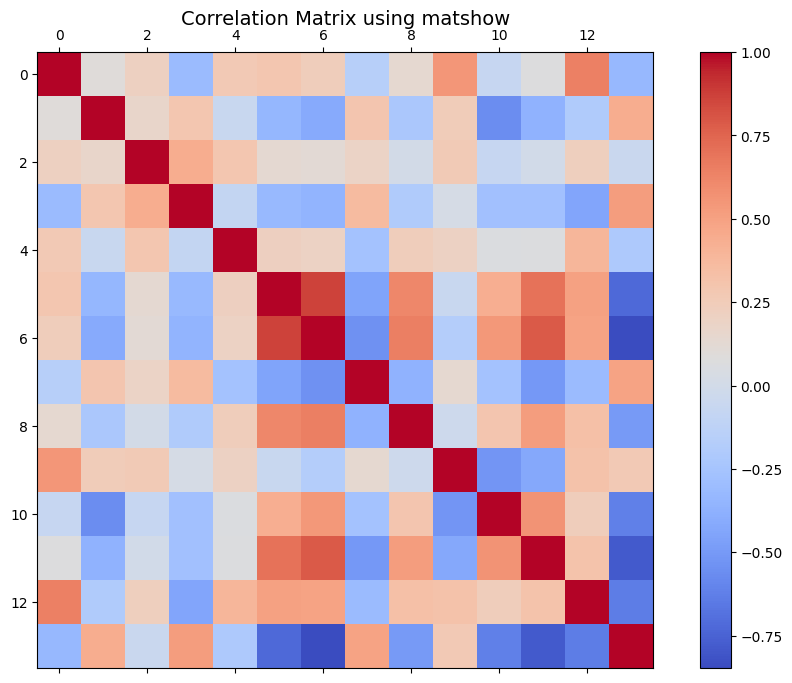

In [ ]:
#Using pandas and matplotlib.matshow, plot the corrlation matrix. Alternatively, using the seabornlibrary
#and heatmap, you can make a heatmap of the correlations that is a bit clearer.
import seaborn as sns
correlation_matrix = df.corr()
fig, ax = plt.subplots(figsize=(12, 8))
cax = ax.matshow(correlation_matrix, cmap='coolwarm')
fig.colorbar(cax) 
plt.title("Correlation Matrix using matshow", pad=20)
plt.show()


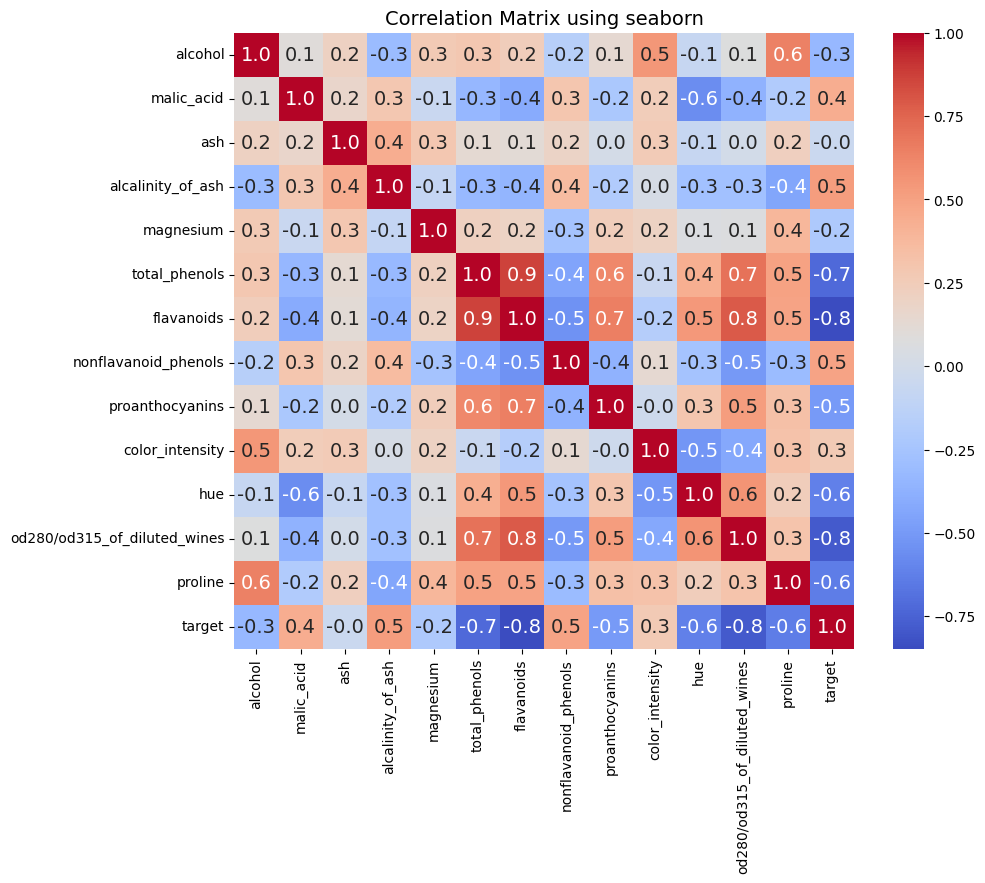

In [59]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.1f', linewidths=0) 
plt.title("Correlation Matrix using seaborn")
plt.show()


In [ ]:
#Repeat questions 10-12 for the two variables with the highest correlation with wine variety. Is the data
#linearly separable?

#Allready pick the right two variables with the highest correlation with wine variety. The data is linearly separable in these two dimensions. It is possible to draw a stright line separating the two classes.

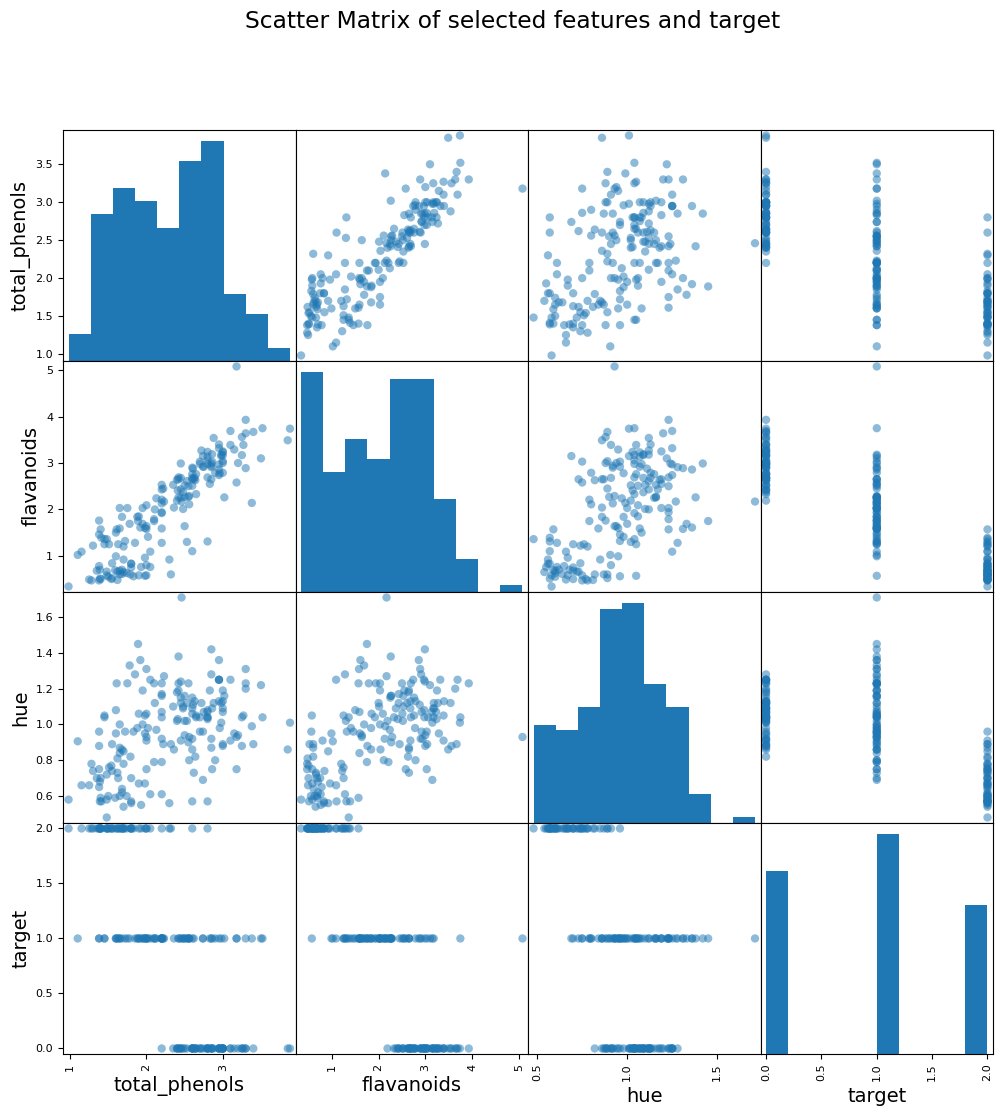

In [ ]:
#Choose the three variables that have the highest linear correlation with the target. Using scatter_matrix
#in pandas.plotting, create a 4x4 matrix of plots showing these three features and the target.

from pandas.plotting import scatter_matrix

var1 = ['total_phenols']
var2 = ['flavanoids'] 
var3 = ['hue']
#var3 = ['proline']
  
colums_to_plot = var1 + var2 + var3 + ['target']

scatter_matrix(df[colums_to_plot], figsize=(12, 12), diagonal='hist', marker='o')

plt.suptitle("Scatter Matrix of selected features and target")
plt.show()